<a href="https://colab.research.google.com/github/mdfaiyazmutadayin/Dengue-Prediction/blob/main/Dengue_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import the pandas library
import pandas as pd

# Mount Google Drive (assuming you are in a Colab environment)
from google.colab import drive
drive.mount('/content/drive')

# Define the path to the CSV file
path = '/content/drive/My Drive/dataset.csv'

# Read the CSV file into a pandas DataFrame
initial_data = pd.read_csv(path)

Mounted at /content/drive


In [ ]:
initial_data.head()


,Gender,Age,NS1,IgG,IgM,Area,AreaType,HouseType,District,Outcome
0,Female,45,0,0,0,Mirpur,Undeveloped,Building,Dhaka,0
1,Male,17,0,0,1,Chawkbazar,Developed,Building,Dhaka,0
2,Female,29,0,0,0,Paltan,Undeveloped,Other,Dhaka,0
3,Female,63,1,1,0,Motijheel,Developed,Other,Dhaka,1
4,Male,22,0,0,0,Gendaria,Undeveloped,Building,Dhaka,0


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Define the bins and labels
bins = [0, 10, 20, 30, 40, 50, 60, 70]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70']

# Create the AgeGroup column
# Changed 'data' to 'initial_data'
initial_data['AgeGroup'] = pd.cut(initial_data['Age'], bins=bins, labels=labels, right=False)

# Remove any rows with missing Outcome, Gender, or AgeGroup
# Changed 'data' to 'initial_data'
initial_data.dropna(subset=['Outcome', 'Gender', 'AgeGroup'], inplace=True)

# Custom color scales
gender_colors = {'Male': '#FF6B6B', 'Female': '#4ECDC4'}
age_colors = px.colors.qualitative.Set3

# Plot outcomes by gender
# Changed 'data' to 'initial_data'
fig_gender = px.histogram(initial_data, x='Outcome', color='Gender', barmode='group', text_auto=True,
                          title='Dengue Outcomes by Gender',
                          labels={'Outcome': 'Outcome', 'Gender': 'Gender', 'count': 'Number of Cases'},
                          category_orders={"Outcome": sorted(initial_data['Outcome'].unique())},
                          color_discrete_map=gender_colors)

fig_gender.update_layout(xaxis_title='Outcome', yaxis_title='Number of Cases', bargap=0.2)

# Plot outcomes by age group
# Changed 'data' to 'initial_data'
fig_age = px.histogram(initial_data, x='Outcome', color='AgeGroup', barmode='group', text_auto=True,
                       title='Dengue Outcomes by Age Group',
                       labels={'Outcome': 'Outcome', 'AgeGroup': 'Age Group', 'count': 'Number of Cases'},
                       category_orders={"Outcome": sorted(initial_data['Outcome'].unique()), "AgeGroup": labels},
                       color_discrete_sequence=age_colors)

fig_age.update_layout(xaxis_title='Outcome', yaxis_title='Number of Cases', bargap=0.2)

# Function to generate textual explanation
# Changed 'data' to 'initial_data' in function signature and calls within the function
def generate_explanation(fig, dataframe, group_column):
    outcomes = dataframe['Outcome'].unique()
    groups = dataframe[group_column].unique()

    total_cases = len(dataframe)
    explanation = f"Analysis of {total_cases} Dengue cases:\n\n"

    for outcome in outcomes:
        outcome_data = dataframe[dataframe['Outcome'] == outcome]
        outcome_percent = (len(outcome_data) / total_cases) * 100
        explanation += f"{outcome} cases: {len(outcome_data)} ({outcome_percent:.1f}% of total)\n"

        for group in groups:
            group_outcome_data = outcome_data[outcome_data[group_column] == group]
            if len(group_outcome_data) > 0:
                group_outcome_percent = (len(group_outcome_data) / len(outcome_data)) * 100
                explanation += f"  - {group}: {len(group_outcome_data)} ({group_outcome_percent:.1f}% of {outcome} cases)\n"

        explanation += "\n"

    # Add actionable insights
    highest_outcome = dataframe['Outcome'].value_counts().index[0]
    most_affected_group = dataframe[dataframe['Outcome'] == highest_outcome][group_column].value_counts().index[0]

    explanation += "Key Insights and Actions:\n"
    explanation += f"1. The most common outcome is '{highest_outcome}', with the {group_column} '{most_affected_group}' being most affected.\n"
    explanation += f"2. Focus prevention efforts on the {group_column} '{most_affected_group}' to potentially reduce '{highest_outcome}' cases.\n"
    explanation += "3. Investigate factors contributing to outcome differences across groups.\n"
    explanation += "4. Develop targeted awareness campaigns for high-risk groups.\n"
    explanation += "5. Allocate resources to support the most affected groups and improve overall outcomes.\n"

    return explanation

# Generate and display explanations
# Changed 'data' to 'initial_data'
gender_explanation = generate_explanation(fig_gender, initial_data, 'Gender')
age_explanation = generate_explanation(fig_age, initial_data, 'AgeGroup')

# Display the plots and explanations
fig_gender.show()
print("\nExplanation for Dengue Outcomes by Gender:")
print(gender_explanation)

fig_age.show()
print("\nExplanation for Dengue Outcomes by Age Group:")
print(age_explanation)


Explanation for Dengue Outcomes by Gender:
Analysis of 1000 Dengue cases:

0 cases: 467 (46.7% of total)
  - Female: 243 (52.0% of 0 cases)
  - Male: 224 (48.0% of 0 cases)

1 cases: 533 (53.3% of total)
  - Female: 281 (52.7% of 1 cases)
  - Male: 252 (47.3% of 1 cases)

Key Insights and Actions:
1. The most common outcome is '1', with the Gender 'Female' being most affected.
2. Focus prevention efforts on the Gender 'Female' to potentially reduce '1' cases.
3. Investigate factors contributing to outcome differences across groups.
4. Develop targeted awareness campaigns for high-risk groups.
5. Allocate resources to support the most affected groups and improve overall outcomes.




Explanation for Dengue Outcomes by Age Group:
Analysis of 1000 Dengue cases:

0 cases: 467 (46.7% of total)
  - 41-50: 75 (16.1% of 0 cases)
  - 11-20: 82 (17.6% of 0 cases)
  - 21-30: 90 (19.3% of 0 cases)
  - 61-70: 46 (9.9% of 0 cases)
  - 31-40: 81 (17.3% of 0 cases)
  - 51-60: 81 (17.3% of 0 cases)
  - 0-10: 12 (2.6% of 0 cases)

1 cases: 533 (53.3% of total)
  - 41-50: 112 (21.0% of 1 cases)
  - 11-20: 99 (18.6% of 1 cases)
  - 21-30: 77 (14.4% of 1 cases)
  - 61-70: 46 (8.6% of 1 cases)
  - 31-40: 92 (17.3% of 1 cases)
  - 51-60: 82 (15.4% of 1 cases)
  - 0-10: 25 (4.7% of 1 cases)

Key Insights and Actions:
1. The most common outcome is '1', with the AgeGroup '41-50' being most affected.
2. Focus prevention efforts on the AgeGroup '41-50' to potentially reduce '1' cases.
3. Investigate factors contributing to outcome differences across groups.
4. Develop targeted awareness campaigns for high-risk groups.
5. Allocate resources to support the most affected groups and improve ove

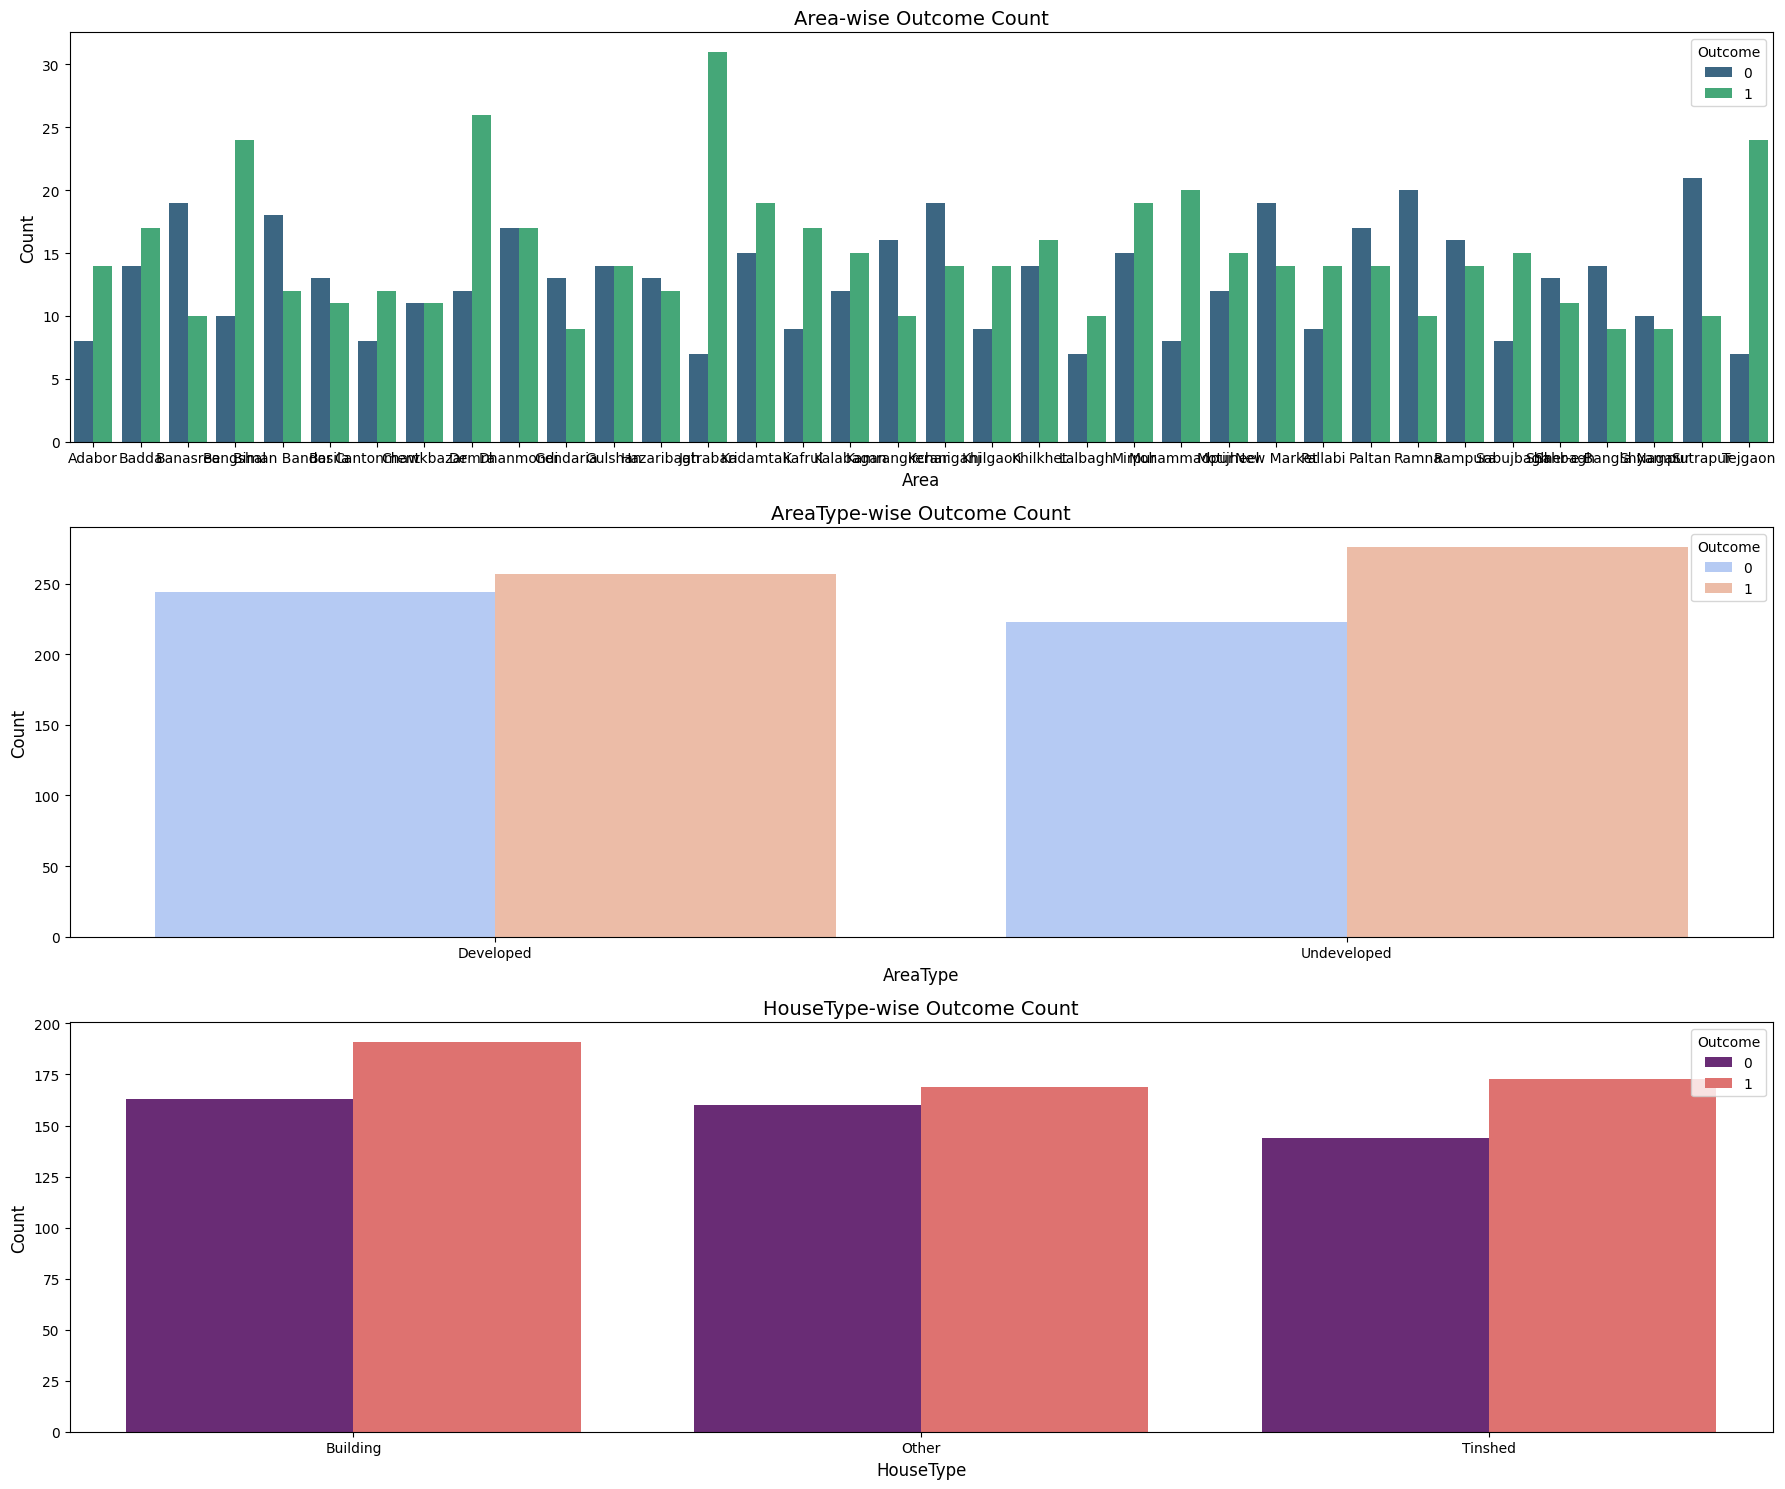

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Area অনুযায়ী Outcome গুনতে
# Changed 'df' to 'initial_data'
area_outcome_count = initial_data.groupby(['Area', 'Outcome']).size().reset_index(name='Count')

# 2. AreaType অনুযায়ী Outcome গুনতে
# Changed 'df' to 'initial_data'
area_type_outcome_count = initial_data.groupby(['AreaType', 'Outcome']).size().reset_index(name='Count')

# 3. HouseType অনুযায়ী Outcome গুনতে
# Changed 'df' to 'initial_data'
house_type_outcome_count = initial_data.groupby(['HouseType', 'Outcome']).size().reset_index(name='Count')

# Visualizations
plt.figure(figsize=(18, 15))

# Area-এর Outcome বার চার্ট
plt.subplot(3, 1, 1)
sns.barplot(
    data=area_outcome_count,
    x='Area',
    y='Count',
    hue='Outcome',
    palette='viridis'
)
plt.title('Area-wise Outcome Count', fontsize=14)
plt.xlabel('Area', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Outcome', loc='upper right')

# AreaType-এর Outcome বার চার্ট
plt.subplot(3, 1, 2)
sns.barplot(
    data=area_type_outcome_count,
    x='AreaType',
    y='Count',
    hue='Outcome',
    palette='coolwarm'
)
plt.title('AreaType-wise Outcome Count', fontsize=14)
plt.xlabel('AreaType', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Outcome', loc='upper right')

# HouseType-এর Outcome বার চার্ট
plt.subplot(3, 1, 3)
sns.barplot(
    data=house_type_outcome_count,
    x='HouseType',
    y='Count',
    hue='Outcome',
    palette='magma'
)
plt.title('HouseType-wise Outcome Count', fontsize=14)
plt.xlabel('HouseType', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Outcome', loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Drop unnecessary columns
df = initial_data.drop(['Gender', 'District','IgG' ,'Area'], axis=1, errors='ignore')

In [ ]:
df.head()

,Age,NS1,IgM,AreaType,HouseType,Outcome
0,45,0,0,Undeveloped,Building,0
1,17,0,1,Developed,Building,0
2,29,0,0,Undeveloped,Other,0
3,63,1,0,Developed,Other,1
4,22,0,0,Undeveloped,Building,0


In [ ]:
import pandas as pd
from sklearn.utils import resample



# Function for under-sampling
def undersample(target_col):
    df_majority = df[df[target_col] == df[target_col].value_counts().idxmax()]
    df_minority = df[df[target_col] == df[target_col].value_counts().idxmin()]
    df_majority_downsampled = resample(df_majority,
                                       replace=False,
                                       n_samples=len(df_minority),
                                       random_state=42)
    return pd.concat([df_majority_downsampled, df_minority])

# Function for over-sampling
def oversample( target_col):
    df_majority = df[df[target_col] == df[target_col].value_counts().idxmax()]
    df_minority = df[df[target_col] == df[target_col].value_counts().idxmin()]
    df_minority_upsampled = resample(df_minority,
                                     replace=True,
                                     n_samples=len(df_majority),
                                     random_state=42)
    return pd.concat([df_majority, df_minority_upsampled])

# Store results in dataframes


df_igm_under = undersample( 'Outcome')
df_igm_over  = oversample( 'Outcome')

print("Balanced datasets stored in memory.")

Balanced datasets stored in memory.


In [ ]:
count_zeros = (df['Outcome'] == 0).sum()
print("Number of 0s in 'outcome' column:", count_zeros)

count_zeros = (df['Outcome'] == 1).sum()
print("Number of 1s in 'outcome' column:", count_zeros)

Number of 0s in 'outcome' column: 467
Number of 1s in 'outcome' column: 533


In [ ]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Separate features and target
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# ----- Over Sampling -----
ros = RandomOverSampler(random_state=42)
X_over, y_over = ros.fit_resample(X, y)

# ----- Under Sampling -----
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X, y)

# Match original shape by rejoining sampled targets to the original DataFrame
# First create default columns with NaNs
df['outcome_over_samp'] = pd.NA
df['outcome_under_samp'] = pd.NA



# Fill under sampled labels in first len(y_under) rows
df.loc[:len(y_under)-1, 'outcome_under_samp'] = y_under.values

In [ ]:
count_zeros = (df['outcome_under_samp'] == 0).sum()
print("Number of 0s in 'outcome' column:", count_zeros)

count_zeros = (df['outcome_under_samp'] == 1).sum()
print("Number of 1s in 'outcome' column:", count_zeros)

Number of 0s in 'outcome' column: 467
Number of 1s in 'outcome' column: 467


Spearman Correlation Matrix (without IgG):
              Age       NS1       IgM   Outcome
Age      1.000000 -0.009888  0.049791 -0.011858
NS1     -0.009888  1.000000  0.045991  0.972313
IgM      0.049791  0.045991  1.000000  0.023380
Outcome -0.011858  0.972313  0.023380  1.000000


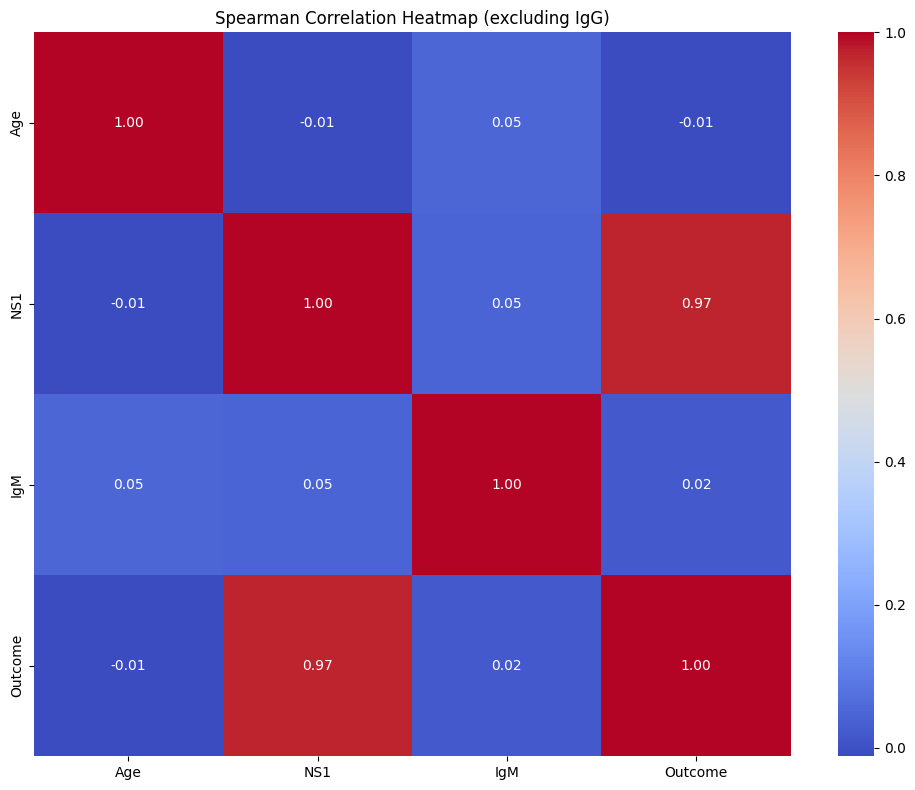

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns, excluding 'IgG'
numerical_data = initial_data._get_numeric_data().drop(columns=['IgG'])

# Compute Spearman correlation matrix
spearman_corr = numerical_data.corr(method='spearman')

# Display correlation matrix
print("Spearman Correlation Matrix (without IgG):")
print(spearman_corr)

# Plot heatmap for better visualization
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap (excluding IgG)")
plt.tight_layout()
plt.show()


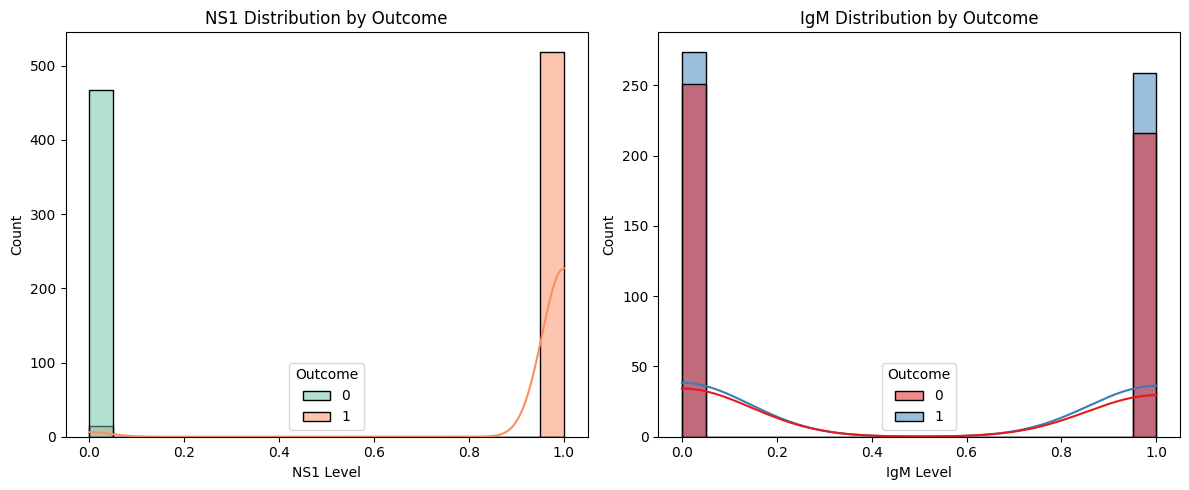

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataset is already loaded into 'initial_data'
df = initial_data.copy()

# Plot histograms of NS1 and IgM for each Outcome class
plt.figure(figsize=(12, 5))

# Histogram for NS1
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='NS1', hue='Outcome', kde=True, bins=20, palette='Set2')
plt.title("NS1 Distribution by Outcome")
plt.xlabel("NS1 Level")
plt.ylabel("Count")

# Histogram for IgM
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='IgM', hue='Outcome', kde=True, bins=20, palette='Set1')
plt.title("IgM Distribution by Outcome")
plt.xlabel("IgM Level")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Copy original data
df = initial_data.copy()

# Identify numerical features for normalization
numerical_features = ['Age']  # Add more if needed

# Initialize Min-Max Scaler
scaler = MinMaxScaler()

# Normalize numerical features
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Keep binary features like NS1 and IgM as is (already binary)
# No changes needed for them
print("Normalized Data Sample:")
print(df.head())


Normalized Data Sample:
   Gender       Age  NS1  IgG  IgM        Area     AreaType HouseType  \
0  Female  0.649123    0    0    0      Mirpur  Undeveloped  Building   
1    Male  0.157895    0    0    1  Chawkbazar    Developed  Building   
2  Female  0.368421    0    0    0      Paltan  Undeveloped     Other   
3  Female  0.964912    1    1    0   Motijheel    Developed     Other   
4    Male  0.245614    0    0    0    Gendaria  Undeveloped  Building   

  District  Outcome  
0    Dhaka        0  
1    Dhaka        0  
2    Dhaka        0  
3    Dhaka        1  
4    Dhaka        0  


In [ ]:
import pandas as pd
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, confusion_matrix

# Separate features and target
# Drop the newly created columns with pd.NA before defining X
X = df.drop(columns=['Outcome', 'outcome_over_samp', 'outcome_under_samp','IgG'], errors='ignore')
y = df['Outcome']

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=['number']).columns

# Create a column transformer to apply one-hot encoding to categorical features
# 'passthrough' leaves numerical columns as they are
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])

# Apply preprocessing to the entire feature set before sampling and splitting
X_processed = preprocessor.fit_transform(X)

# Convert X_processed back to a DataFrame (optional, but can be helpful)
# Note: Get feature names after one-hot encoding if you want meaningful column names
# This part can be complex depending on the OneHotEncoder output.
# For simplicity, we'll proceed with the sparse matrix or array from preprocessor
# if the transformers return that format.

# ----- Under Sampling -----
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_processed, y) # Use the processed X here

# ----- Over Sampling (if needed, apply to the processed X as well) -----
# ros = RandomOverSampler(random_state=42)
# X_over, y_over = ros.fit_resample(X_processed, y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_under, y_under, test_size=0.2, random_state=42)

# Initialize base models
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)
ann = MLPClassifier(random_state=42, max_iter=1000) # Increased max_iter for potential convergence

# Train base models
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
xgb.fit(X_train, y_train)
ann.fit(X_train, y_train)

# Get predictions from base models on the test set
knn_pred = knn.predict(X_test)
dt_pred = dt.predict(X_test)
xgb_pred = xgb.predict(X_test)
ann_pred = ann.predict(X_test)

# Combine predictions into a new feature set for the meta-model
# Reshape predictions if necessary (ANN might return a different shape)
# Ensure all predictions are 1D arrays
knn_pred = knn_pred.ravel()
dt_pred = dt_pred.ravel()
xgb_pred = xgb_pred.ravel()
ann_pred = ann_pred.ravel()

meta_features = pd.DataFrame({
    'knn_pred': knn_pred,
    'dt_pred': dt_pred,
    'xgb_pred': xgb_pred,
    'ann_pred': ann_pred
})

# Initialize meta-model
meta_model = LogisticRegression(random_state=42)

# Generate predictions of base models on the training set for meta-model training
knn_train_pred = knn.predict(X_train)
dt_train_pred = dt.predict(X_train)
xgb_train_pred = xgb.predict(X_train)
ann_train_pred = ann.predict(X_train)

meta_train_features = pd.DataFrame({
    'knn_pred': knn_train_pred.ravel(),
    'dt_pred': dt_train_pred.ravel(),
    'xgb_pred': xgb_train_pred.ravel(),
    'ann_pred': ann_train_pred.ravel()
})

# Train the meta-model
meta_model.fit(meta_train_features, y_train)

# Get final predictions from the meta-model on the test set
final_predictions = meta_model.predict(meta_features)

# Calculate evaluation metrics
f1 = f1_score(y_test, final_predictions)
recall = recall_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions)
accuracy = accuracy_score(y_test, final_predictions)
conf_matrix = confusion_matrix(y_test, final_predictions)

# Print the evaluation results
print(f"F1 Score: {f1}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
plt.show()

F1 Score: 0.9720670391061452
Recall: 0.9456521739130435
Precision: 1.0
Accuracy: 0.9732620320855615
Confusion Matrix:
[[95  0]
 [ 5 87]]



Model Evaluation Metrics (%):
               Accuracy  Precision  Recall  F1 Score
KNN               93.58      97.62   89.13     93.18
Decision Tree     96.79      98.86   94.57     96.67
XGBoost           97.33     100.00   94.57     97.21
ANN               97.33     100.00   94.57     97.21
Meta-Model        97.33     100.00   94.57     97.21


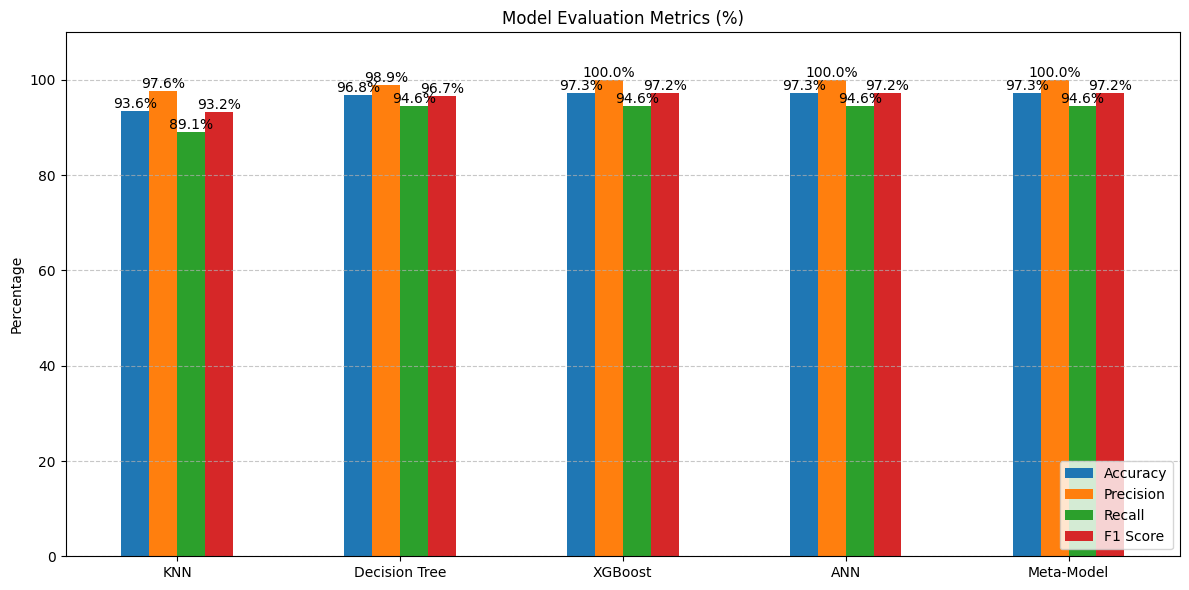

In [ ]:
import matplotlib.pyplot as plt

# Function to evaluate models
def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

# Evaluate each model
results = {
    'KNN': evaluate_model(y_test, knn_pred),
    'Decision Tree': evaluate_model(y_test, dt_pred),
    'XGBoost': evaluate_model(y_test, xgb_pred),
    'ANN': evaluate_model(y_test, ann_pred),
    'Meta-Model': evaluate_model(y_test, final_predictions)
}

# Convert to DataFrame and multiply by 100 to show percentage
results_df = pd.DataFrame(results).T * 100  # Multiply to convert to percentage

print("\nModel Evaluation Metrics (%):")
print(results_df.round(2))

# Plotting
ax = results_df.plot(kind='bar', figsize=(12, 6))
plt.title("Model Evaluation Metrics (%)")
plt.ylabel("Percentage")
plt.ylim(0, 110)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Annotate bars with percentage values
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.show()


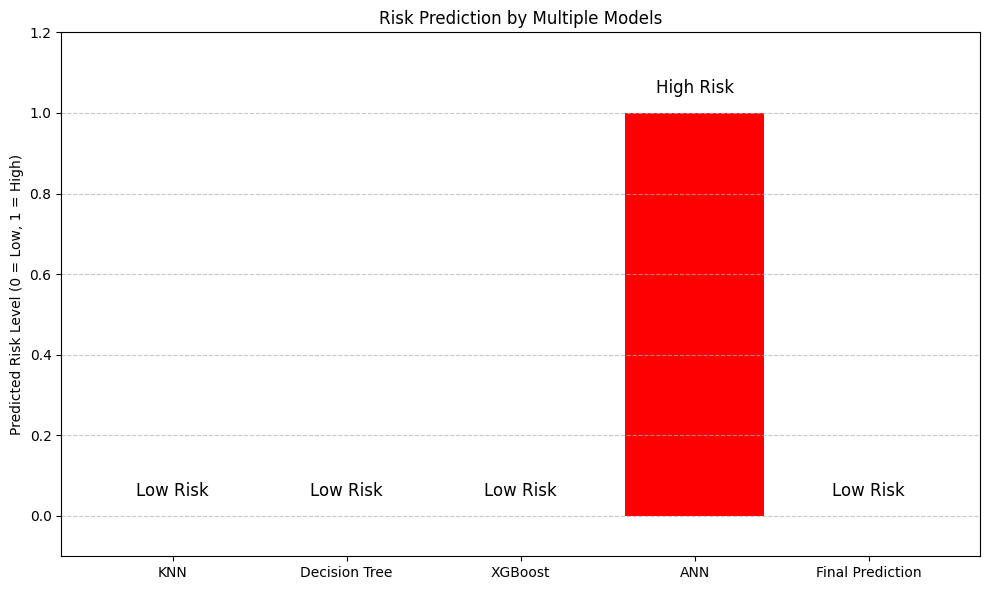

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from imblearn.under_sampling import RandomUnderSampler

# Load the dataset
path = '/content/drive/MyDrive/dataset.csv'
initial_data = pd.read_csv(path)

df = initial_data.copy()

# Select relevant columns for modeling
features = ['Age',  'IgM', 'AreaType', 'HouseType']
X = df[features]
y = df['Outcome']  # Binary: 0 = Low, 1 = High

# Preprocessing: OneHot encode categorical variables
categorical = ['AreaType', 'HouseType']
numerical = ['Age', 'IgM']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', 'passthrough', numerical)
])

# Process features
X_processed = preprocessor.fit_transform(X)

# Undersample for balance
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_processed, y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Initialize models
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42)
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
ann = MLPClassifier(random_state=42, max_iter=1000)
meta_model = LogisticRegression(random_state=42)

# Fit models
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
xgb.fit(X_train, y_train)
ann.fit(X_train, y_train)

# Meta-model training
meta_train = pd.DataFrame({
    'knn_pred': knn.predict(X_train),
    'dt_pred': dt.predict(X_train),
    'xgb_pred': xgb.predict(X_train),
    'ann_pred': ann.predict(X_train)
})
meta_model.fit(meta_train, y_train)

# ----------- USER INPUT SECTION ------------

# You can change these values to test other cases
user_input = pd.DataFrame([{
    'Age': 20,
    'IgM': 0,
    'AreaType': 'Undeveloped',
    'HouseType': 'Other'
}])

# Process input
user_processed = preprocessor.transform(user_input)

# Predict with base models
knn_pred = knn.predict(user_processed)[0]
dt_pred = dt.predict(user_processed)[0]
xgb_pred = xgb.predict(user_processed)[0]
ann_pred = ann.predict(user_processed)[0]

# Meta model prediction
meta_features = pd.DataFrame([{
    'knn_pred': knn_pred,
    'dt_pred': dt_pred,
    'xgb_pred': xgb_pred,
    'ann_pred': ann_pred
}])
final_pred = meta_model.predict(meta_features)[0]

# ----------- VISUALIZATION SECTION ------------

# Risk mapping
def map_risk(value):
    return "Low Risk" if value == 0 else "High Risk"

model_preds = [knn_pred, dt_pred, xgb_pred, ann_pred, final_pred]
model_names = ['KNN', 'Decision Tree', 'XGBoost', 'ANN', 'Final Prediction']
labels = [map_risk(v) for v in model_preds]
colors = ['green' if v == 0 else 'red' for v in model_preds]

# Bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, model_preds, color=colors)
for bar, label in zip(bars, labels):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, label, ha='center', fontsize=12)

plt.ylim(-0.1, 1.2)
plt.title('Risk Prediction by Multiple Models')
plt.ylabel('Predicted Risk Level (0 = Low, 1 = High)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
